In [ ]:
!git clone https://github.com/JaehaKim97/SR4IR
%cd SR4IR

!pip install lpips

Cloning into 'SR4IR'...
remote: Enumerating objects: 367, done.
remote: Counting objects: 100% (367/367), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 367 (delta 154), reused 319 (delta 130), pack-reused 0 (from 0)
Receiving objects: 100% (367/367), 1.59 MiB | 5.19 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/content/SR4IR
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.0 MB/s eta 0:00:00


In [105]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import lpips
import os

In [106]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [107]:
import os

folder_path = "/content/drive/MyDrive/car_dataset"
print(os.listdir(folder_path))

['val', 'test', 'train']


In [108]:
%cd /content/SR4IR

/content/SR4IR


In [109]:
!pip install ptflops

In [110]:
from ptflops import get_model_complexity_info

In [119]:
%cd /content/SR4IR/src

!python main.py -opt ../options/cls/StanfordCars/114_SR4IR_edsr_x4.yml

/content/SR4IR/src
Not using distributed mode
Model [sr4ir_cls_model] is created
Path already exists. Rename it to experiments/cls/sr4ir_edsr_x4_archived_20260328_144910
Path already exists. Rename it to tb_loggers/cls/sr4ir_edsr_x4_archived_20260328_144910
2026-03-28 14:49:10.580095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774709350.601874   52893 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774709350.609178   52893 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774709350.627889   52893 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W000

In [120]:
%cd /content/SR4IR/src

/content/SR4IR/src


In [121]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import yaml

In [122]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [123]:
transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root="/content/drive/MyDrive/car_dataset/test",
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Number of test images:", len(test_dataset))
print("Classes:", test_dataset.classes)

Number of test images: 45
Classes: ['Audi 100 Sedan 1994', 'BMW 1 Series Convertible 2012', 'Cadillac CTS-V Sedan 2012', 'Dodge Caravan Minivan 1997', 'Eagle Talon Hatchback 1998', 'Ferrari 458 Italia Convertible 2012', 'Ford Edge SUV 2012', 'GMC Acadia SUV 2012', 'Infiniti G Coupe IPL 2012']


In [124]:
from models.cls.sr4ir_cls_model import SR4IRClassificationModel

opt_path = "../options/cls/StanfordCars/114_SR4IR_edsr_x4.yml"

with open(opt_path, 'r') as f:
    opt = yaml.safe_load(f)


opt['dist'] = False
opt['rank'] = 0
opt['world_size'] = 1

model = SR4IRClassificationModel(opt)

Path already exists. Rename it to experiments/cls/sr4ir_edsr_x4_archived_20260328_145220
Path already exists. Rename it to tb_loggers/cls/sr4ir_edsr_x4_archived_20260328_145220
Random seed : 200
Arch [edsr] is created (net_sr)
Arch [ResNet18] is created (net_cls)
Size different, ignore [fc.weight]: crt_net: torch.Size([40, 512]); load_net: torch.Size([1000, 512])
Size different, ignore [fc.bias]: crt_net: torch.Size([40]); load_net: torch.Size([1000])
--> Load net_cls model from ResNet18_Weights.IMAGENET1K_V1.
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth


In [125]:
model_path = "/content/net_cls_epoch_30.pth"

model.net_cls.load_state_dict(torch.load(model_path))
model.net_cls.to(device)
model.net_cls.eval()

print("Model loaded successfully")

Model loaded successfully


In [126]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model.net_cls(images)
        _, preds = outputs.max(1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

acc = 100 * correct / total

print(f"\n Test Accuracy: {acc:.2f}%")


 Test Accuracy: 8.89%


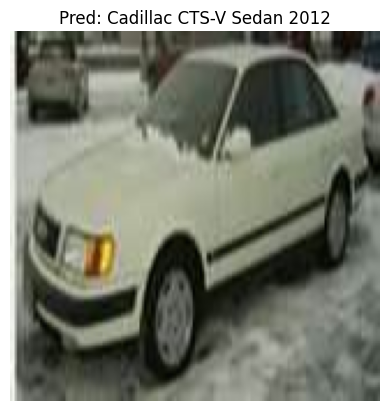

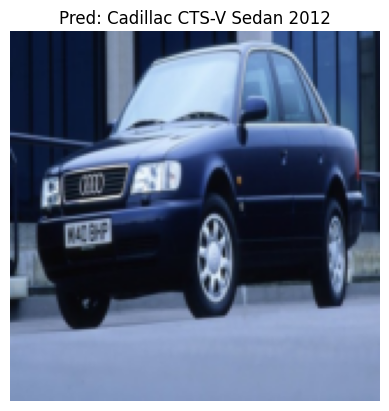

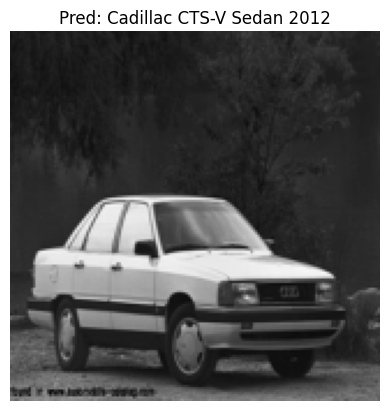

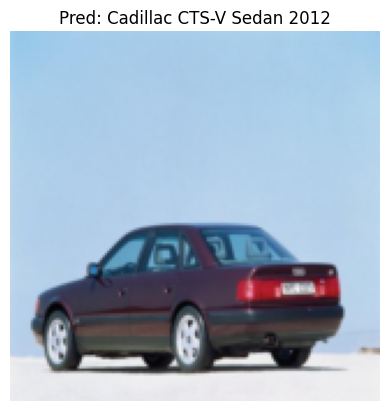

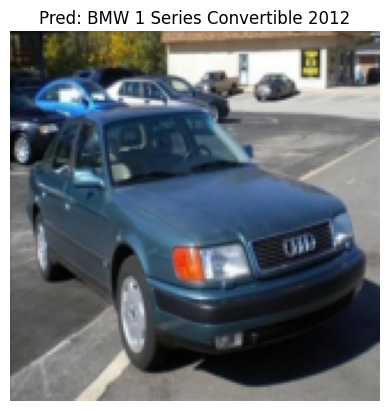

In [127]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))
images = images.to(device)

outputs = model.net_cls(images)
_, preds = outputs.max(1)

for i in range(5):
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.title(f"Pred: {test_dataset.classes[preds[i]]}")
    plt.axis('off')
    plt.show()

In [129]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model.net_cls(images)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Predictions collected")

Predictions collected


In [130]:
cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[0 1 4 0 0 0 0 0 0]
 [0 0 5 0 0 0 0 0 0]
 [0 1 4 0 0 0 0 0 0]
 [0 1 3 0 0 0 0 0 1]
 [0 2 3 0 0 0 0 0 0]
 [0 1 3 0 0 0 0 0 1]
 [0 1 4 0 0 0 0 0 0]
 [3 0 2 0 0 0 0 0 0]
 [1 0 4 0 0 0 0 0 0]]


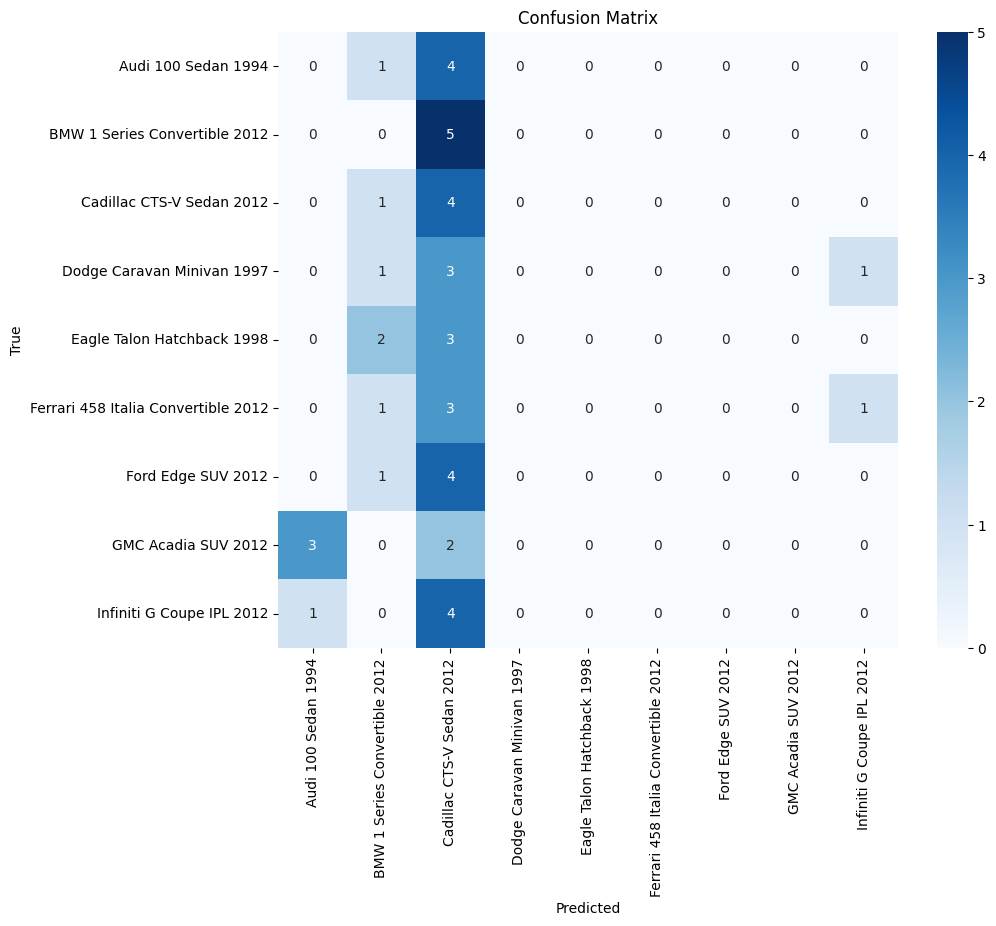

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()